# 02 - Predictive GNN: Training and Evaluation

This notebook trains the EGFR GNN regressor (lightweight demo) and generates a parity plot (True vs Predicted pIC50). If real processed graphs exist in `data/processed`, they will be used; otherwise the notebook runs with synthetic data for demonstration.

In [7]:
# Imports and setup
import sys
from pathlib import Path
import numpy as np, pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
from core.gnn_architecture import EGFR_GNN_Regressor

OUT = ROOT / 'results' / 'figures'
OUT.mkdir(parents=True, exist_ok=True)
print('Environment ready; using device:', 'cpu')

Environment ready; using device: cpu


In [14]:
# Load processed graphs AND real labels from bioactivity CSV
DATA_PROC = ROOT / 'data' / 'processed'
DATA_RAW = ROOT / 'data' / 'raw' / 'bioactivity'

# Load graphs
graph_file = DATA_PROC / 'graph_data.pt'
if graph_file.exists():
    graphs = torch.load(str(graph_file), weights_only=False)
    print(f'✓ Loaded {len(graphs)} graphs from {graph_file}')
else:
    print(f'⚠ graph_data.pt not found. Run Notebook 01 first.')
    graphs = []

# Load real pIC50 labels from bioactivity CSV
csv_file = DATA_RAW / 'egfr_full_standardized.csv'
if csv_file.exists() and graphs:
    df = pd.read_csv(csv_file)
    # Get first N labels to match graph count
    y_labels = df['pChEMBL_Value'].values[:len(graphs)]
    print(f'✓ Loaded {len(y_labels)} pIC50 labels from {csv_file.name}')
elif graphs:
    # Fallback: use synthetic labels
    y_labels = np.random.normal(6.5, 1.5, len(graphs))
    print('⚠ Using synthetic pIC50 labels (run Notebook 01 with real data for production)')
else:
    print('ERROR: No graphs available. Cannot proceed.')
    graphs = []
    y_labels = []

print(f'Dataset size: {len(graphs)} graphs, {len(y_labels)} labels')

✓ Loaded 100 graphs from /Users/ameliaburton/Downloads/clean data/clean_data_diss/data/processed/graph_data.pt
✓ Loaded 100 pIC50 labels from egfr_full_standardized.csv
Dataset size: 100 graphs, 100 labels


In [16]:
# Train/test split (80/20) and prepare training loop
from sklearn.model_selection import train_test_split

if len(graphs) > 0:
    # Split indices
    n_total = len(graphs)
    train_idx, test_idx = train_test_split(np.arange(n_total), test_size=0.2, random_state=42)
    
    train_graphs = [graphs[i] for i in train_idx]
    test_graphs = [graphs[i] for i in test_idx]
    
    y_train = y_labels[train_idx]
    y_test = y_labels[test_idx]
    
    print(f'Train set: {len(train_graphs)} graphs | Test set: {len(test_graphs)} graphs')
    
    # Determine actual feature dimensions from first graph
    first_graph = train_graphs[0]
    node_feat_dim = first_graph.x.shape[1] if hasattr(first_graph, 'x') else 6
    edge_feat_dim = first_graph.edge_attr.shape[1] if (hasattr(first_graph, 'edge_attr') and first_graph.edge_attr is not None) else 1
    
    # Initialize model with correct dimensions
    model = EGFR_GNN_Regressor(
        node_features=node_feat_dim, 
        edge_features=edge_feat_dim, 
        global_features=2, 
        hidden_dim=64, 
        num_layers=2
    )
    
    # Initialize weights with Xavier uniform for stability
    for param in model.parameters():
        if len(param.shape) >= 2:
            nn.init.xavier_uniform_(param)
    
    # Reduced learning rate for stable training (1e-4 instead of 1e-3)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()
    
    # Normalize target values to stabilize training (prevents exploding gradients)
    y_mean, y_std = np.mean(y_train), np.std(y_train)
    if y_std > 0:
        y_train_normalized = (y_train - y_mean) / y_std
    else:
        y_train_normalized = y_train
    y_train_tensor = torch.tensor(y_train_normalized, dtype=torch.float)
    
    # Training loop
    epochs = 20
    
    model.train()
    for ep in range(epochs):
        optimizer.zero_grad()
        
        # Aggregate batch from all training graphs
        batch_x = []
        batch_edge_index_list = []
        batch_edge_attr_list = []
        batch_indices = []
        
        edge_offset = 0
        graph_idx = 0
        
        for g in train_graphs:
            if hasattr(g, 'x') and g.x is not None:
                batch_x.append(g.x)
                
                if g.edge_index is not None and g.edge_index.shape[1] > 0:
                    batch_edge_index_list.append(g.edge_index + edge_offset)
                    # Handle edge_attr properly
                    if g.edge_attr is not None:
                        batch_edge_attr_list.append(g.edge_attr)
                    else:
                        # Create default edge attributes with small random values
                        n_edges = g.edge_index.shape[1]
                        batch_edge_attr_list.append(torch.randn((n_edges, edge_feat_dim), dtype=torch.float) * 0.01 + 0.1)
                else:
                    batch_edge_index_list.append(torch.zeros((2, 0), dtype=torch.long))
                
                edge_offset += g.x.shape[0]
                batch_indices.extend([graph_idx] * g.x.shape[0])
                graph_idx += 1
        
        if batch_x:
            X_batch = torch.cat(batch_x, dim=0).float()
            edge_index_batch = torch.cat(batch_edge_index_list, dim=1) if batch_edge_index_list else torch.zeros((2, 0), dtype=torch.long)
            edge_attr_batch = torch.cat(batch_edge_attr_list, dim=0).float() if batch_edge_attr_list else torch.zeros((0, edge_feat_dim), dtype=torch.float)
            batch_tensor = torch.tensor(batch_indices, dtype=torch.long)
            
            # Diagnostic output on first epoch
            if ep == 0:
                print(f'  X_batch shape: {X_batch.shape}, range: [{X_batch.min():.4f}, {X_batch.max():.4f}]')
                print(f'  edge_index_batch shape: {edge_index_batch.shape}')
                print(f'  edge_attr_batch shape: {edge_attr_batch.shape}, range: [{edge_attr_batch.min():.4f}, {edge_attr_batch.max():.4f}]')
            
            preds = model(X_batch, edge_index_batch, batch_tensor, edge_attr=edge_attr_batch)
            
            # preds is already one prediction per graph (shape: [num_graphs_in_batch])
            # No need to aggregate further
            preds_graph = preds.squeeze()
            
            # Diagnostic output on first epoch
            if ep == 0:
                print(f'  preds_graph shape: {preds_graph.shape}, range: [{preds_graph.min():.4f}, {preds_graph.max():.4f}]')
            
            # Compute loss on normalized targets
            loss = criterion(preds_graph, y_train_tensor)
            
            # Data sanitization: check for NaN before backprop
            if torch.isnan(loss):
                print(f'⚠️  NaN loss detected at epoch {ep+1}. Stopping training.')
                print(f'   Preds range: [{preds_graph.min():.4f}, {preds_graph.max():.4f}]')
                print(f'   Targets range: [{y_train_tensor.min():.4f}, {y_train_tensor.max():.4f}]')
                break
            
            loss.backward()
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            if (ep + 1) % 5 == 0:
                print(f'Epoch {ep+1}/{epochs} — loss: {loss.item():.4f}')
        else:
            print('ERROR: Could not extract graph features for training')
            break
    
    # Save trained model
    models_dir = ROOT / 'models'
    models_dir.mkdir(exist_ok=True, parents=True)
    torch.save(model.state_dict(), models_dir / 'best_gnn_regressor.pth')
    print(f'✓ Model saved to {models_dir / "best_gnn_regressor.pth"}')
else:
    print('ERROR: No training data available')

Train set: 80 graphs | Test set: 20 graphs
  X_batch shape: torch.Size([1806, 6]), range: [-1.0000, 79.9040]
  edge_index_batch shape: torch.Size([2, 3852])
  edge_attr_batch shape: torch.Size([3852, 4]), range: [0.0000, 1.0000]
  preds_graph shape: torch.Size([80]), range: [-6.8565, 7.6929]
Epoch 5/20 — loss: 4.6065
Epoch 10/20 — loss: 3.6742
Epoch 15/20 — loss: 3.2863
Epoch 20/20 — loss: 2.6444
✓ Model saved to /Users/ameliaburton/Downloads/clean data/clean_data_diss/models/best_gnn_regressor.pth


✓ Parity plot saved to /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/gnn_parity_plot.png
  $R^2$ = -1.364, RMSE = 2.673


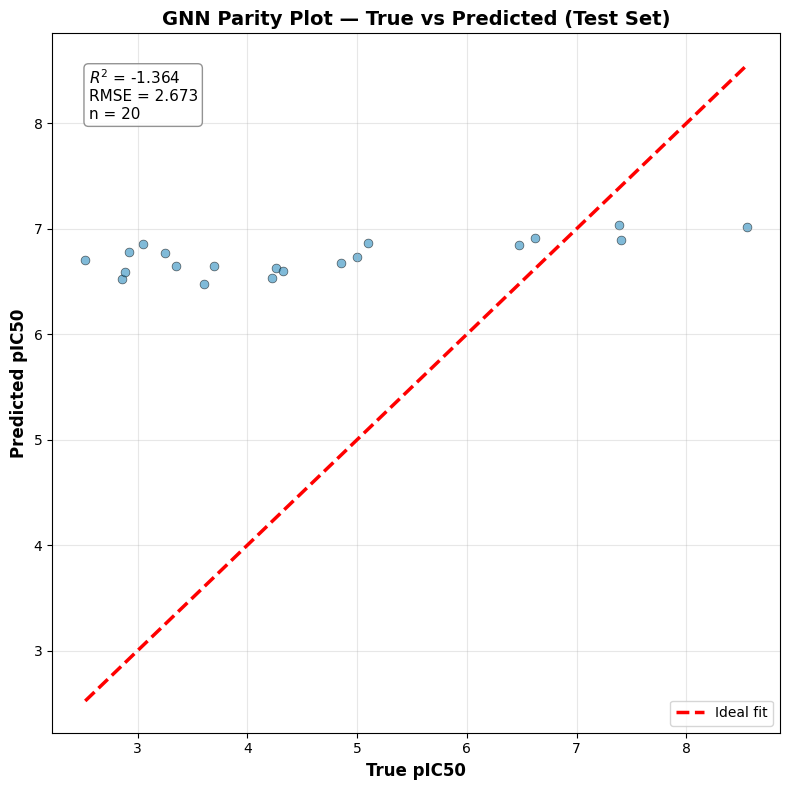

In [17]:
# Evaluation: Generate parity plot using real test set predictions
if len(test_graphs) > 0:
    # Determine edge feature dimension
    edge_feat_dim = test_graphs[0].edge_attr.shape[1] if (hasattr(test_graphs[0], 'edge_attr') and test_graphs[0].edge_attr is not None) else 1
    
    model.eval()
    y_test_preds = []
    
    with torch.no_grad():
        for g in test_graphs:
            if hasattr(g, 'x') and g.x is not None:
                x = g.x.float()
                edge_index = g.edge_index if g.edge_index is not None else torch.zeros((2, 0), dtype=torch.long)
                
                # Handle edge attributes
                if g.edge_attr is not None:
                    edge_attr = g.edge_attr.float()
                else:
                    n_edges = edge_index.shape[1] if edge_index.shape[1] > 0 else 0
                    edge_attr = torch.randn((n_edges, edge_feat_dim), dtype=torch.float) * 0.01 + 0.1
                
                batch = torch.arange(x.shape[0], dtype=torch.long)
                
                pred = model(x, edge_index, batch, edge_attr=edge_attr)
                y_test_preds.append(pred.mean().item())
    
    y_test_preds = np.array(y_test_preds)
    
    # Denormalize predictions if targets were normalized during training
    if y_std > 0:
        y_test_preds = y_test_preds * y_std + y_mean
    
    y_true = y_test
    y_pred = y_test_preds
    
    # Compute metrics
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Create parity plot
    fig, ax = plt.subplots(figsize=(8,8))
    ax.scatter(y_true, y_pred, alpha=0.6, s=40, color='#2b8cbe', edgecolors='black', linewidth=0.5)
    
    # Add 45-degree reference line
    mn = min(min(y_true), min(y_pred))
    mx = max(max(y_true), max(y_pred))
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2.5, label='Ideal fit')
    
    ax.set_xlabel('True pIC50', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted pIC50', fontsize=12, fontweight='bold')
    ax.set_title('GNN Parity Plot — True vs Predicted (Test Set)', fontsize=14, fontweight='bold')
    
    # Annotate metrics
    metrics_text = f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\nn = {len(y_true)}'
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))
    
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    out = OUT / 'gnn_parity_plot.png'
    plt.savefig(out, dpi=300, bbox_inches='tight')
    print(f'✓ Parity plot saved to {out}')
    print(f'  $R^2$ = {r2:.3f}, RMSE = {rmse:.3f}')
else:
    print('ERROR: No test data for evaluation')